Dataset extracted!


/tmp/ipython-input-3631972807.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(train_path + f, delim_whitespace=True, header=None)
/tmp/ipython-input-3631972807.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(train_path + f, delim_whitespace=True, header=None)
/tmp/ipython-input-3631972807.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(train_path + f, delim_whitespace=True, header=None)
/tmp/ipython-input-3631972807.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(train_path + f, delim_whitespace=True, heade

X shape: (7352, 128, 6) y shape: (7352,)
Training RNN...
Epoch 1/30 - Train Loss: 1.7892, Val Loss: 1.7857
Epoch 5/30 - Train Loss: 1.1509, Val Loss: 1.1332
Epoch 10/30 - Train Loss: 1.2985, Val Loss: 1.1935
Epoch 15/30 - Train Loss: 1.6802, Val Loss: 1.4512
Epoch 20/30 - Train Loss: 1.2601, Val Loss: 1.1836
Epoch 25/30 - Train Loss: 1.1994, Val Loss: 1.1234
Epoch 30/30 - Train Loss: 1.1527, Val Loss: 1.1313
Training LSTM...
Epoch 1/30 - Train Loss: 1.6037, Val Loss: 1.2261
Epoch 5/30 - Train Loss: 1.1868, Val Loss: 1.1873
Epoch 10/30 - Train Loss: 1.3702, Val Loss: 1.1903
Epoch 15/30 - Train Loss: 1.1503, Val Loss: 1.1544
Epoch 20/30 - Train Loss: 1.2883, Val Loss: 1.6989
Epoch 25/30 - Train Loss: 1.6955, Val Loss: 1.6833
Epoch 30/30 - Train Loss: 1.7114, Val Loss: 1.6987
Training GRU...
Epoch 1/30 - Train Loss: 1.7815, Val Loss: 1.6971
Epoch 5/30 - Train Loss: 0.6638, Val Loss: 0.7664
Epoch 10/30 - Train Loss: 0.6119, Val Loss: 0.6113
Epoch 15/30 - Train Loss: 0.5858, Val Loss: 0.585

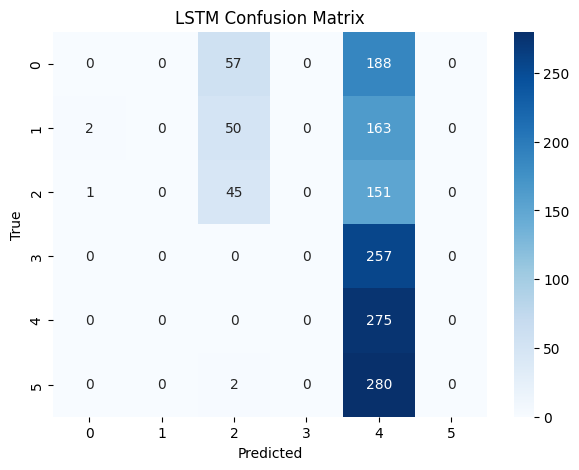

In [2]:

import requests, zipfile, io, os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# 2️⃣ DOWNLOAD & EXTRACT UCI HAR

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))
z.extractall()  # Extract to current folder
print("Dataset extracted!")


# 3️⃣ LOAD RAW INERTIAL SIGNALS

train_path = "UCI HAR Dataset/train/Inertial Signals/"
signal_files = [
    "body_acc_x_train.txt", "body_acc_y_train.txt", "body_acc_z_train.txt",
    "body_gyro_x_train.txt", "body_gyro_y_train.txt", "body_gyro_z_train.txt"
]

signals = []
for f in signal_files:
    data = pd.read_csv(train_path + f, delim_whitespace=True, header=None)
    signals.append(data.values)

X = np.stack(signals, axis=2)  # Shape: (7352, 128, 6)
y = pd.read_csv("UCI HAR Dataset/train/y_train.txt", header=None)[0].values - 1  # 0-based labels

print("X shape:", X.shape, "y shape:", y.shape)


# 4️⃣ TRAIN / VALIDATION SPLIT

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64)


# 5️⃣ DEFINE RNN/LSTM/GRU MODEL

class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, model_type="RNN"):
        super(RNNClassifier, self).__init__()
        self.model_type = model_type
        if model_type == "RNN":
            self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        elif model_type == "GRU":
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        else:
            raise ValueError("model_type must be 'RNN', 'LSTM', or 'GRU'")
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # Take last timestep
        out = self.fc(out)
        return out


# 6️⃣ TRAINING FUNCTION

def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []

    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_batch.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{epochs} - Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")

    return train_losses, val_losses


# 7️⃣ INITIALIZE MODELS

input_size = 6
hidden_size = 128
num_layers = 2
num_classes = 6

rnn_model = RNNClassifier(input_size, hidden_size, num_layers, num_classes, model_type="RNN")
lstm_model = RNNClassifier(input_size, hidden_size, num_layers, num_classes, model_type="LSTM")
gru_model = RNNClassifier(input_size, hidden_size, num_layers, num_classes, model_type="GRU")

# 8️⃣ TRAIN MODELS

print("Training RNN...")
train_model(rnn_model, train_loader, val_loader, epochs=30)

print("Training LSTM...")
train_model(lstm_model, train_loader, val_loader, epochs=30)

print("Training GRU...")
train_model(gru_model, train_loader, val_loader, epochs=30)


# 9️⃣ EVALUATION FUNCTION

def evaluate_model(model, X_val, y_val):
    model.eval()
    with torch.no_grad():
        outputs = model(X_val)
        y_pred = torch.argmax(outputs, dim=1).numpy()
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="weighted")
    cm = confusion_matrix(y_val, y_pred)
    return acc, f1, cm

rnn_acc, rnn_f1, rnn_cm = evaluate_model(rnn_model, X_val, y_val)
lstm_acc, lstm_f1, lstm_cm = evaluate_model(lstm_model, X_val, y_val)
gru_acc, gru_f1, gru_cm = evaluate_model(gru_model, X_val, y_val)

print("\nRNN Accuracy:", rnn_acc, "F1-score:", rnn_f1)
print("LSTM Accuracy:", lstm_acc, "F1-score:", lstm_f1)
print("GRU Accuracy:", gru_acc, "F1-score:", gru_f1)

# 🔟 PLOT CONFUSION MATRIX (example for LSTM)

plt.figure(figsize=(7,5))
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


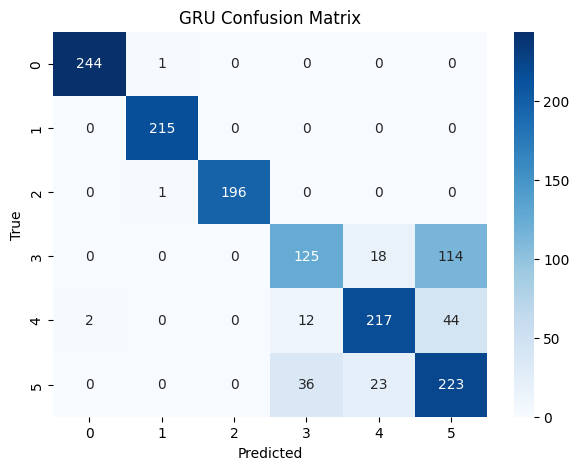

In [5]:

# 🔟 PLOT CONFUSION MATRIX (example for GRU)

plt.figure(figsize=(7,5))
sns.heatmap(gru_cm, annot=True, fmt='d', cmap='Blues')
plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

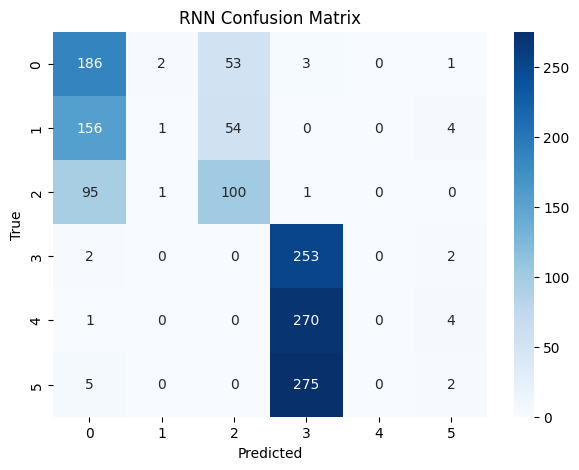

In [6]:

# 🔟 PLOT CONFUSION MATRIX (example for RNN)

plt.figure(figsize=(7,5))
sns.heatmap(rnn_cm, annot=True, fmt='d', cmap='Blues')
plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()